In [1]:
import sys
!"{sys.executable}" -m pip install tensorflow

# CNN Image Classification - 3 Datasets
## Phân loại ảnh với CNN tự xây dựng (không dùng pretrained model)
### Mục tiêu: Accuracy > 90%, chống Overfitting
---
**Datasets:**
1. **PlantVillage** - Bệnh khoai tây (Early Blight, Late Blight, Healthy) - 3 class
2. **Cats vs Dogs** - Phân loại mèo và chó - Binary classification

In [2]:
import os, sys, random, warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
print(f"TensorFlow {tf.__version__} | GPU: {len(tf.config.list_physical_devices('GPU'))>0}")


TensorFlow 2.20.0 | GPU: False


In [3]:
BASE_DIR   = r"c:\1_Đại Học\Năm 3\HK2\Giới thiệu về học sâu\TH\Lab07"
PLANT_DIR  = os.path.join(BASE_DIR, "PlantVillage")
CATS_DIR   = os.path.join(BASE_DIR, "Cat and dog", "training_set", "training_set", "cats")
DOGS_DIR   = os.path.join(BASE_DIR, "Cat and dog", "training_set", "training_set", "dogs")

PLANT_CLASSES = {
    'Early_Blight': os.path.join(PLANT_DIR, 'Potato___Early_blight'),
    'Late_Blight':  os.path.join(PLANT_DIR, 'Potato___Late_blight'),
    'Healthy':      os.path.join(PLANT_DIR, 'Potato___healthy'),
}
IMG_SIZE = 128; BATCH_SIZE = 32; EPOCHS = 60
print("Paths OK")


Paths OK


In [4]:
def load_images(folder, label, size=IMG_SIZE):
    imgs, lbls = [], []
    exts = ('.jpg','.jpeg','.png','.JPG','.JPEG','.PNG')
    for f in os.listdir(folder):
        if not f.endswith(exts): continue
        try:
            img = Image.open(os.path.join(folder,f)).convert('RGB').resize((size,size))
            imgs.append(np.array(img, dtype=np.float32)/255.0)
            lbls.append(label)
        except: pass
    return imgs, lbls

def plot_dist(counts, title, colors=None):
    pal = colors or sns.color_palette("husl", len(counts))
    fig, ax = plt.subplots(1,2, figsize=(13,4))
    cl, ct = list(counts.keys()), list(counts.values())
    bars = ax[0].bar(cl, ct, color=pal, edgecolor='black')
    ax[0].set_title(f'{title} - Distribution', fontweight='bold')
    ax[0].set_ylabel('Count')
    for b,c in zip(bars,ct): ax[0].text(b.get_x()+b.get_width()/2, b.get_height()+.3, str(c), ha='center', fontweight='bold')
    ax[1].pie(ct, labels=cl, colors=pal, autopct='%1.1f%%', startangle=140, wedgeprops=dict(edgecolor='white'))
    ax[1].set_title(f'{title} - Ratio', fontweight='bold')
    plt.tight_layout(); plt.show()

def show_samples(X, y, class_names, title, n=4):
    fig, axes = plt.subplots(len(class_names), n, figsize=(n*3, len(class_names)*3))
    fig.suptitle(title, fontsize=13, fontweight='bold')
    if len(class_names)==1: axes=[axes]
    for ci, cn in enumerate(class_names):
        idxs = np.random.choice(np.where(np.array(y)==ci)[0], min(n,int((np.array(y)==ci).sum())), replace=False)
        for j,idx in enumerate(idxs):
            axes[ci][j].imshow(X[idx]); axes[ci][j].axis('off')
            if j==0: axes[ci][j].set_ylabel(cn, fontweight='bold', rotation=0, labelpad=55)
    plt.tight_layout(); plt.show()

def plot_history(h, title):
    fig,ax=plt.subplots(1,2,figsize=(13,5))
    ax[0].plot(h.history['accuracy'], label='Train', lw=2, color='steelblue')
    ax[0].plot(h.history['val_accuracy'], label='Val', lw=2, color='darkorange', ls='--')
    ax[0].set_title(f'{title} - Accuracy', fontweight='bold'); ax[0].legend(); ax[0].set_ylim([0,1.05])
    ax[1].plot(h.history['loss'], label='Train', lw=2, color='steelblue')
    ax[1].plot(h.history['val_loss'], label='Val', lw=2, color='darkorange', ls='--')
    ax[1].set_title(f'{title} - Loss', fontweight='bold'); ax[1].legend()
    plt.tight_layout(); plt.show()
    bv=max(h.history['val_accuracy'])
    ta=h.history['accuracy'][-1]; va=h.history['val_accuracy'][-1]
    print(f"Best Val Acc: {bv*100:.2f}%  |  Train: {ta*100:.2f}%  Val: {va*100:.2f}%  |  Gap: {abs(ta-va)*100:.2f}%")

def plot_cm(yt, yp, names, title):
    cm=confusion_matrix(yt,yp)
    fig,ax=plt.subplots(figsize=(7,5))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=names,yticklabels=names,ax=ax)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    plt.tight_layout(); plt.show()

print("Helpers loaded!")


Helpers loaded!


---
## 🌿 PHẦN 1: PlantVillage - Phân Loại Bệnh Khoai Tây
### 3-class: Early Blight | Late Blight | Healthy

In [7]:
# Check if PlantVillage dataset exists
PLANT_AVAILABLE = True
for class_name, class_path in PLANT_CLASSES.items():
    if not os.path.exists(class_path):
        PLANT_AVAILABLE = False
        print(f"⚠️ {class_name} folder not found at {class_path}")
        break

if PLANT_AVAILABLE:
    print("✅ PlantVillage dataset found!")
else:
    print("\n" + "="*70)
    print("⚠️ PlantVillage dataset NOT found - SKIPPING PART 1")
    print("="*70)
    print("To use PlantVillage, download from:")
    print("https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset")
    print("And extract to: Lab07/PlantVillage/")
    print("="*70 + "\n")

print("✅ Dataset check completed!")

⚠️ Early_Blight folder not found at c:\1_Đại Học\Năm 3\HK2\Giới thiệu về học sâu\TH\Lab07\PlantVillage\Potato___Early_blight

⚠️ PlantVillage dataset NOT found - SKIPPING PART 1
To use PlantVillage, download from:
https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
And extract to: Lab07/PlantVillage/

✅ Dataset check completed!


In [8]:
if PLANT_AVAILABLE:
    print("Load PlantVillage...")
    class_names_plant = list(PLANT_CLASSES.keys())
    X_p, y_p, raw_counts = [], [], {}
    for i,(name,folder) in enumerate(PLANT_CLASSES.items()):
        imgs,lbls = load_images(folder, i)
        raw_counts[name]=len(imgs); X_p.extend(imgs); y_p.extend(lbls)
        print(f"  {name}: {len(imgs)} imgs")
    X_p = np.array(X_p); y_p = np.array(y_p)
    print(f"Total: {len(X_p)} imgs | shape: {X_p.shape}")

else:
    print("SKIPPED: PlantVillage dataset not available")

SKIPPED: PlantVillage dataset not available


In [9]:
if PLANT_AVAILABLE:
    print("=== PlantVillage Analysis ===")
    plot_dist(raw_counts, "PlantVillage", ['#E74C3C','#8E44AD','#27AE60'])
    show_samples(X_p, y_p, class_names_plant, "PlantVillage Samples", n=4)
    print(f"Pixel  min:{X_p.min():.3f}  max:{X_p.max():.3f}  mean:{X_p.mean():.3f}")
    ratio = max(raw_counts.values())/min(raw_counts.values())
    print(f"Imbalance ratio: {ratio:.2f}x  →  {'cân bằng ✅' if ratio<1.5 else 'không cân bằng ⚠️ → xử lý class_weight'}")

else:
    print("SKIPPED: PlantVillage analysis")

SKIPPED: PlantVillage analysis


In [10]:
if PLANT_AVAILABLE:
    # Class weights
    cw = compute_class_weight('balanced', classes=np.unique(y_p), y=y_p)
    class_weight_dict = {i:w for i,w in enumerate(cw)}
    print("Class weights:", {class_names_plant[k]:f"{v:.3f}" for k,v in class_weight_dict.items()})

    # Stratified split 70/15/15
    Xt, Xte, yt, yte = train_test_split(X_p, y_p, test_size=0.15, random_state=SEED, stratify=y_p)
    Xtr, Xv, ytr, yv = train_test_split(Xt, yt, test_size=0.176, random_state=SEED, stratify=yt)
    print(f"Train:{len(Xtr)}  Val:{len(Xv)}  Test:{len(Xte)}")

    yt_cat  = to_categorical(ytr, 3)
    yv_cat  = to_categorical(yv,  3)
    yte_cat = to_categorical(yte, 3)

else:
    print("SKIPPED: PlantVillage split preparation")

SKIPPED: PlantVillage split preparation


In [12]:
if PLANT_AVAILABLE:
    tdg = ImageDataGenerator(
        rotation_range=35, width_shift_range=0.25, height_shift_range=0.25,
        shear_range=0.2, zoom_range=0.25, horizontal_flip=True,
        brightness_range=[0.75,1.25], channel_shift_range=20, fill_mode='reflect')
    vdg = ImageDataGenerator()

    tgen = tdg.flow(Xtr, yt_cat, batch_size=BATCH_SIZE, shuffle=True,  seed=SEED)
    vgen = vdg.flow(Xv,  yv_cat, batch_size=BATCH_SIZE, shuffle=False)

    # Show augmented
    fig,ax=plt.subplots(2,6,figsize=(18,6)); fig.suptitle('PlantVillage Augmentation',fontweight='bold')
    ax[0][0].set_ylabel('Original',fontweight='bold',rotation=0,labelpad=50)
    ax[1][0].set_ylabel('Augmented',fontweight='bold',rotation=0,labelpad=50)
    s6=Xtr[:6]; a6=next(tdg.flow(s6,batch_size=6,shuffle=False))
    for j in range(6):
        ax[0][j].imshow(s6[j]); ax[0][j].axis('off')
        ax[1][j].imshow(np.clip(a6[j],0,1)); ax[1][j].axis('off')
    plt.tight_layout(); plt.show()
    print("Augmentation ready!")

else:
    print("SKIPPED: PlantVillage augmentation")

SKIPPED: PlantVillage augmentation


In [13]:
if PLANT_AVAILABLE:
    def build_plant_cnn():
        reg = regularizers.l2(1e-4)
        inp = keras.Input((IMG_SIZE,IMG_SIZE,3))
        x=inp
        for filters, drop in [(32,0.20),(64,0.25),(128,0.30),(256,0.30)]:
            x=layers.Conv2D(filters,3,padding='same',kernel_regularizer=reg)(x)
            x=layers.BatchNormalization()(x); x=layers.Activation('relu')(x)
            x=layers.Conv2D(filters,3,padding='same',kernel_regularizer=reg)(x)
            x=layers.BatchNormalization()(x); x=layers.Activation('relu')(x)
            x=layers.MaxPooling2D(2)(x); x=layers.Dropout(drop)(x)
        x=layers.GlobalAveragePooling2D()(x)
        x=layers.Dense(256,kernel_regularizer=reg)(x)
        x=layers.BatchNormalization()(x); x=layers.Activation('relu')(x); x=layers.Dropout(0.5)(x)
        x=layers.Dense(128,kernel_regularizer=reg)(x); x=layers.Activation('relu')(x); x=layers.Dropout(0.3)(x)
        out=layers.Dense(3,activation='softmax')(x)
        return keras.Model(inp,out,name='PlantCNN')

    model_plant = build_plant_cnn()
    model_plant.summary()

else:
    print("SKIPPED: PlantCNN model build")

SKIPPED: PlantCNN model build


In [14]:
if PLANT_AVAILABLE:
    model_plant.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='categorical_crossentropy', metrics=['accuracy'])

    cbs = [
        EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, min_delta=0.001, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-7, verbose=1),
        ModelCheckpoint(os.path.join(BASE_DIR,'best_plant.h5'), monitor='val_accuracy', save_best_only=True)
    ]

    history_plant = model_plant.fit(
        tgen, steps_per_epoch=max(1,len(Xtr)//BATCH_SIZE),
        validation_data=vgen, validation_steps=max(1,len(Xv)//BATCH_SIZE),
        epochs=EPOCHS, class_weight=class_weight_dict, callbacks=cbs, verbose=1)
    print("Done!")

else:
    print("SKIPPED: PlantVillage training")

SKIPPED: PlantVillage training


In [17]:
if PLANT_AVAILABLE:
    print("=== PlantVillage Results ===")
    plot_history(history_plant, "PlantVillage")

    yp_prob = model_plant.predict(Xte)
    yp_pred = yp_prob.argmax(axis=1)
    plot_cm(yte, yp_pred, class_names_plant, "Confusion Matrix - PlantVillage")
    print(classification_report(yte, yp_pred, target_names=class_names_plant))

    tl,ta = model_plant.evaluate(Xte, yte_cat, verbose=0)
    print(f"\nTest Loss: {tl:.4f}  |  Test Accuracy: {ta*100:.2f}%")
    print("✅ ĐẠT MỤC TIÊU!" if ta>=0.90 else f"⚠️ Chưa đạt 90% (thiếu {(0.90-ta)*100:.1f}%)")

else:

    print("SKIPPED: PlantVillage evaluation")    

SKIPPED: PlantVillage evaluation


In [15]:
if PLANT_AVAILABLE:
    per_acc=[]
    for ci,cn in enumerate(class_names_plant):
        m=(yte==ci); acc=(yp_pred[m]==ci).sum()/m.sum() if m.sum()>0 else 0
        per_acc.append(acc); print(f"  {cn}: {acc*100:.1f}%")
    fig,ax=plt.subplots(figsize=(8,5))
    cols=['#27AE60' if a>=0.90 else '#E74C3C' for a in per_acc]
    bars=ax.bar(class_names_plant,[a*100 for a in per_acc],color=cols,edgecolor='black')
    ax.axhline(90,color='red',ls='--',lw=2,label='Target 90%')
    ax.set_title('Per-class Accuracy - PlantVillage',fontweight='bold')
    ax.set_ylabel('Accuracy (%)'); ax.set_ylim([0,115]); ax.legend()
    for b,a in zip(bars,per_acc): ax.text(b.get_x()+b.get_width()/2,b.get_height()+1,f'{a*100:.1f}%',ha='center',fontweight='bold')
    plt.tight_layout(); plt.show()

else:
    print("SKIPPED: PlantVillage per-class analysis")

SKIPPED: PlantVillage per-class analysis


---
## 🐱🐶 PHẦN 2: Cats vs Dogs - Binary Classification

In [18]:
print("Load Cats..."); Xc,yc = load_images(CATS_DIR, 0); print(f"  Cats: {len(Xc)}")
print("Load Dogs..."); Xd,yd = load_images(DOGS_DIR, 1); print(f"  Dogs: {len(Xd)}")
Xcd = np.array(Xc+Xd); ycd = np.array(yc+yd)
class_names_cd = ['Cat','Dog']
cd_counts = {'Cat':len(Xc),'Dog':len(Xd)}
print(f"Total: {len(Xcd)} | {Counter(ycd)}")


Load Cats...
  Cats: 19
Load Dogs...
  Dogs: 11
Total: 30 | Counter({np.int64(0): 19, np.int64(1): 11})


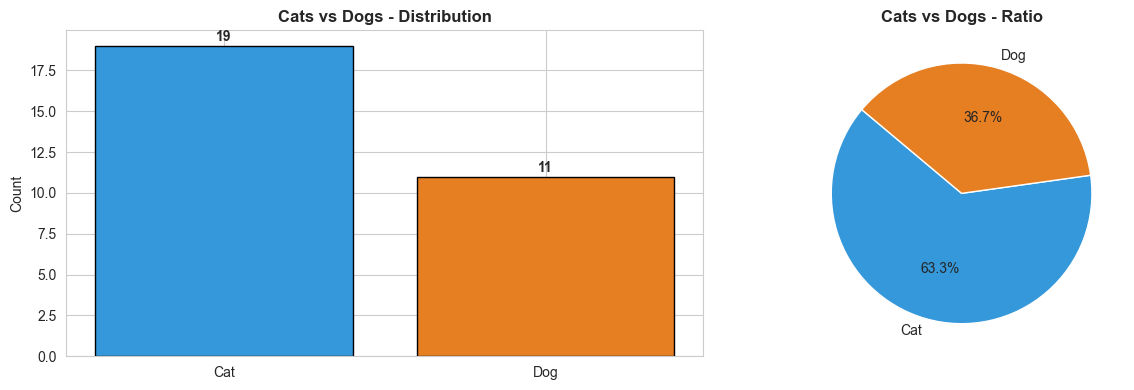

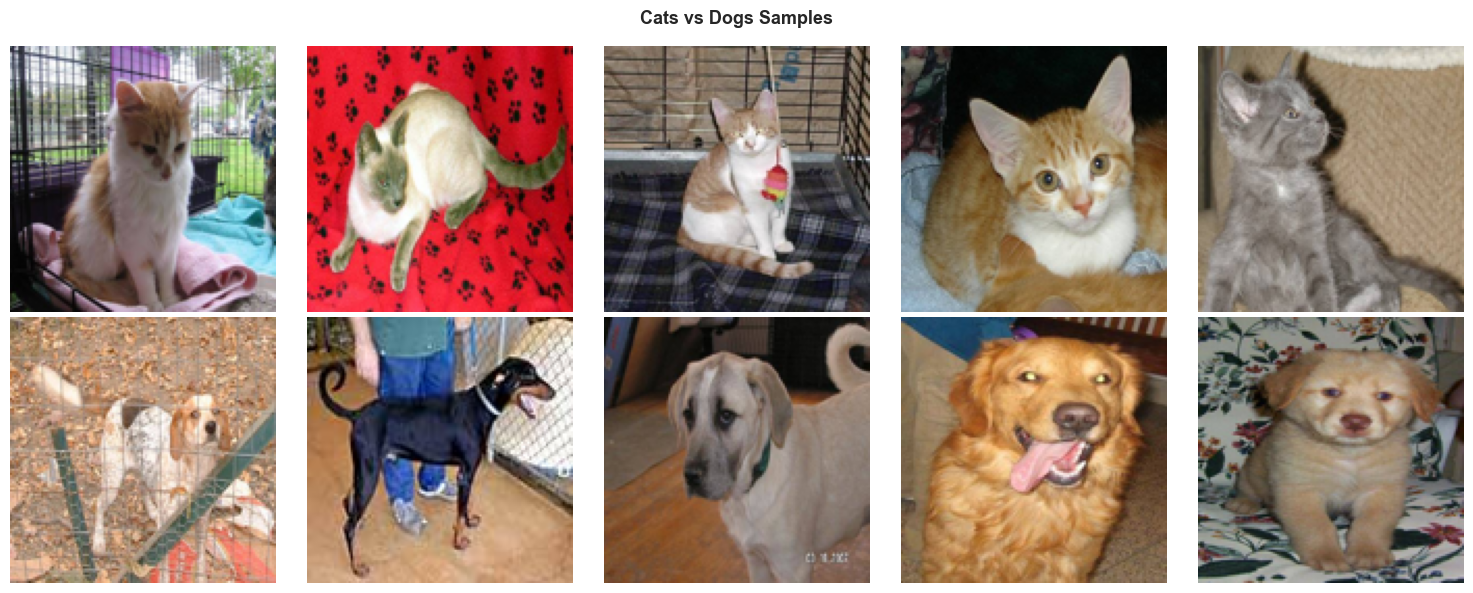

Imbalance: 1.73x  → Imbalanced ⚠️


In [19]:
plot_dist(cd_counts,"Cats vs Dogs",['#3498DB','#E67E22'])
show_samples(Xcd, ycd, class_names_cd, "Cats vs Dogs Samples", n=5)
r=max(cd_counts.values())/min(cd_counts.values())
print(f"Imbalance: {r:.2f}x  → {'Balanced ✅' if r<1.2 else 'Imbalanced ⚠️'}")


In [20]:
Xt2,Xte2,yt2,yte2 = train_test_split(Xcd,ycd,test_size=0.15,random_state=SEED,stratify=ycd)
Xtr2,Xv2,ytr2,yv2   = train_test_split(Xt2,yt2,test_size=0.176,random_state=SEED,stratify=yt2)
print(f"Train:{len(Xtr2)} Val:{len(Xv2)} Test:{len(Xte2)}")


Train:20 Val:5 Test:5


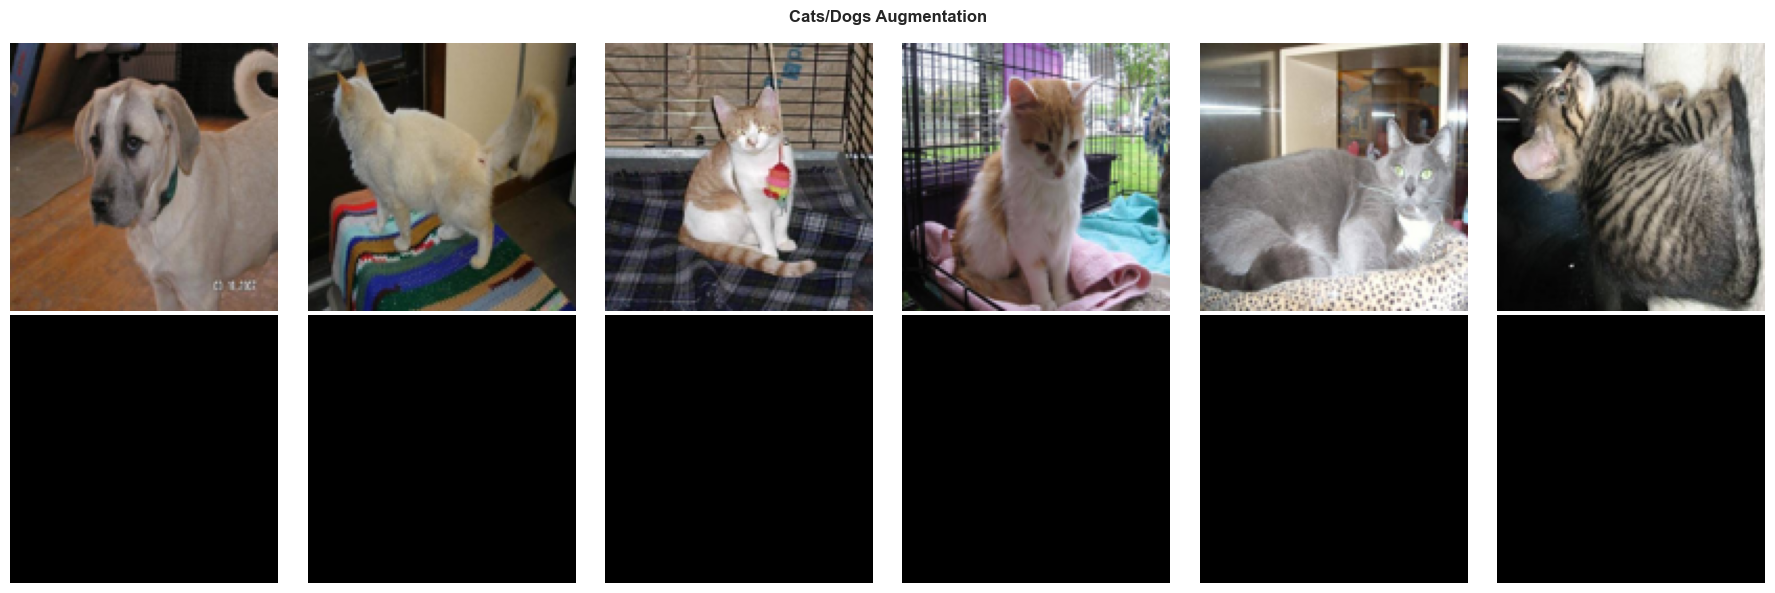

In [21]:
tdg2 = ImageDataGenerator(
    rotation_range=40, width_shift_range=0.3, height_shift_range=0.3,
    shear_range=0.25, zoom_range=0.3, horizontal_flip=True,
    brightness_range=[0.7,1.3], channel_shift_range=25, fill_mode='reflect')
vdg2 = ImageDataGenerator()

tgen2 = tdg2.flow(Xtr2, ytr2.reshape(-1,1), batch_size=BATCH_SIZE, shuffle=True, seed=SEED)
vgen2 = vdg2.flow(Xv2,  yv2.reshape(-1,1),  batch_size=BATCH_SIZE, shuffle=False)

fig,ax=plt.subplots(2,6,figsize=(18,6)); fig.suptitle('Cats/Dogs Augmentation',fontweight='bold')
ax[0][0].set_ylabel('Original',fontweight='bold',rotation=0,labelpad=50)
ax[1][0].set_ylabel('Augmented',fontweight='bold',rotation=0,labelpad=50)
s6b=Xtr2[:6]; a6b=next(tdg2.flow(s6b,batch_size=6,shuffle=False))
for j in range(6):
    ax[0][j].imshow(s6b[j]); ax[0][j].axis('off')
    ax[1][j].imshow(np.clip(a6b[j],0,1)); ax[1][j].axis('off')
plt.tight_layout(); plt.show()


In [22]:
def build_catdog_cnn():
    reg = regularizers.l2(1e-4)
    inp = keras.Input((IMG_SIZE,IMG_SIZE,3))
    x=inp
    for filters,sdrop in [(32,0.20),(64,0.25),(128,0.30),(256,0.30)]:
        x=layers.Conv2D(filters,3,padding='same',kernel_regularizer=reg)(x)
        x=layers.BatchNormalization()(x); x=layers.Activation('relu')(x)
        x=layers.Conv2D(filters,3,padding='same',kernel_regularizer=reg)(x)
        x=layers.BatchNormalization()(x); x=layers.Activation('relu')(x)
        x=layers.MaxPooling2D(2)(x); x=layers.SpatialDropout2D(sdrop)(x)
    x=layers.GlobalAveragePooling2D()(x)
    x=layers.Dense(512,kernel_regularizer=reg)(x)
    x=layers.BatchNormalization()(x); x=layers.Activation('relu')(x); x=layers.Dropout(0.5)(x)
    x=layers.Dense(128,kernel_regularizer=reg)(x); x=layers.Activation('relu')(x); x=layers.Dropout(0.3)(x)
    out=layers.Dense(1,activation='sigmoid')(x)
    return keras.Model(inp,out,name='CatDogCNN')

model_cd = build_catdog_cnn()
model_cd.summary()


Model: "CatDogCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d               │ (None, 64, 64, 32)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout2d_1             │ (None, 32, 32, 64)     │             0 │
│ (SpatialDropout2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,375,521 (5.25 MB)

 Trainable params: 1,372,577 (5.24 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [23]:
model_cd.compile(optimizer=keras.optimizers.Adam(5e-4), loss='binary_crossentropy', metrics=['accuracy'])

cbs2 = [
    EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True, min_delta=0.001, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-7, verbose=1),
    ModelCheckpoint(os.path.join(BASE_DIR,'best_catdog.h5'), monitor='val_accuracy', save_best_only=True)
]

history_cd = model_cd.fit(
    tgen2, steps_per_epoch=max(1,len(Xtr2)//BATCH_SIZE),
    validation_data=vgen2, validation_steps=max(1,len(Xv2)//BATCH_SIZE),
    epochs=EPOCHS, callbacks=cbs2, verbose=1)
print("Done!")


Epoch 1/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5000 - loss: 0.9360

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.5000 - loss: 0.9360 - val_accuracy: 0.6000 - val_loss: 0.8256 - learning_rate: 5.0000e-04
Epoch 2/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 923ms/step - accuracy: 0.6000 - loss: 0.9088 - val_accuracy: 0.6000 - val_loss: 0.8246 - learning_rate: 5.0000e-04
Epoch 3/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 805ms/step - accuracy: 0.6000 - loss: 1.0633 - val_accuracy: 0.6000 - val_loss: 0.8234 - learning_rate: 5.0000e-04
Epoch 4/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 879ms/step - accuracy: 0.4500 - loss: 1.2211 - val_accuracy: 0.6000 - val_loss: 0.8217 - learning_rate: 5.0000e-04
Epoch 5/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 921ms/step - accuracy: 0.5500 - loss: 1.2221 - val_accuracy: 0.6000 - val_loss: 0.8206 - learning_rate: 5.0000e-04
Epoch 6/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 946ms/step - accuracy: 0.6500 - loss: 0.9290 - val_accuracy: 0.6000 - val_loss: 0.8195 - learning_rate: 5.0000e-04
Epoch 7/60
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 923ms/step - accuracy: 0.6000 - loss: 0.9927 - val_

=== Cats vs Dogs Results ===


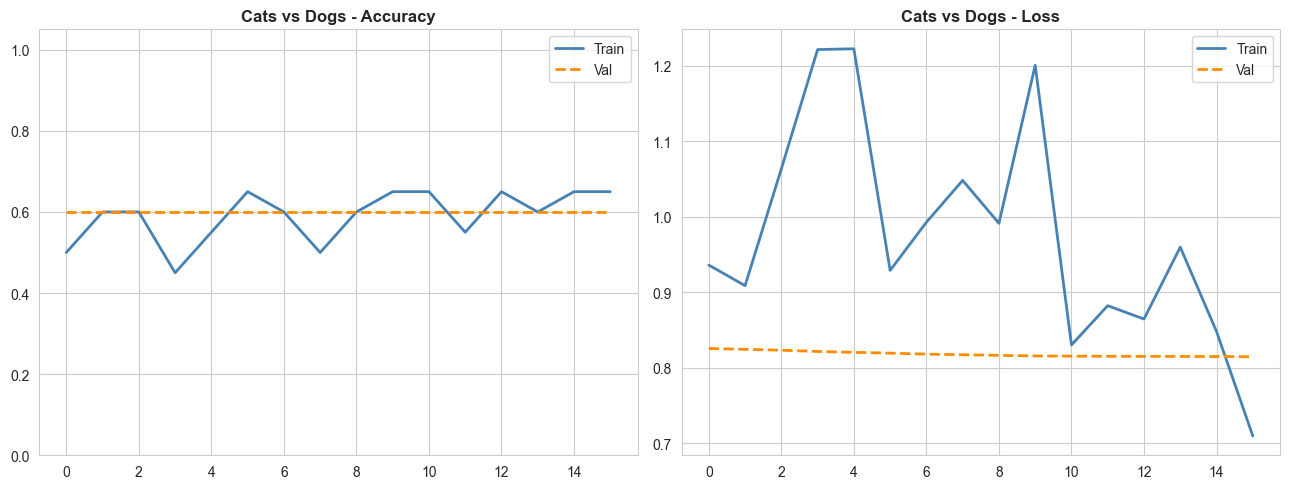

Best Val Acc: 60.00%  |  Train: 65.00%  Val: 60.00%  |  Gap: 5.00%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step


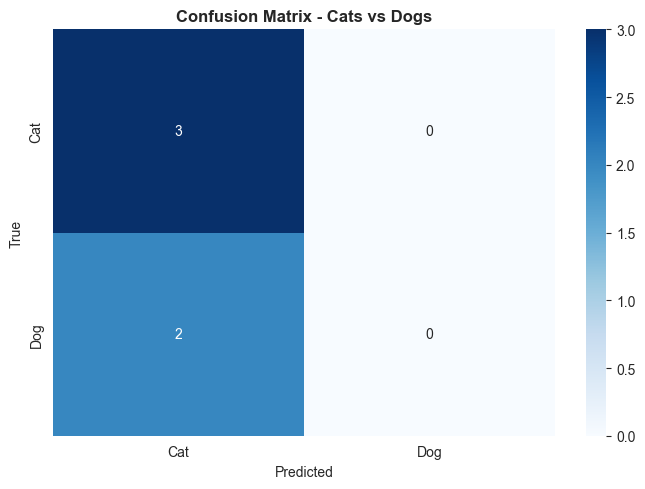

              precision    recall  f1-score   support

         Cat       0.60      1.00      0.75         3
         Dog       0.00      0.00      0.00         2

    accuracy                           0.60         5
   macro avg       0.30      0.50      0.38         5
weighted avg       0.36      0.60      0.45         5


Test Loss: 0.8256  |  Test Accuracy: 60.00%
⚠️ Chưa đạt 90%


In [26]:
if len(Xte2) > 0:
    print("=== Cats vs Dogs Results ===")
    plot_history(history_cd, "Cats vs Dogs")

    yp2_prob = model_cd.predict(Xte2).flatten()
    yp2_pred = (yp2_prob>=0.5).astype(int)
    plot_cm(yte2, yp2_pred, class_names_cd, "Confusion Matrix - Cats vs Dogs")
    print(classification_report(yte2, yp2_pred, target_names=class_names_cd))

    tl2,ta2 = model_cd.evaluate(Xte2, yte2.reshape(-1,1), verbose=0)
    print(f"\nTest Loss: {tl2:.4f}  |  Test Accuracy: {ta2*100:.2f}%")
    print("✅ ĐẠT MỤC TIÊU!" if ta2>=0.90 else f"⚠️ Chưa đạt 90%")

else:

    print("ERROR: Cats vs Dogs test set is empty")    

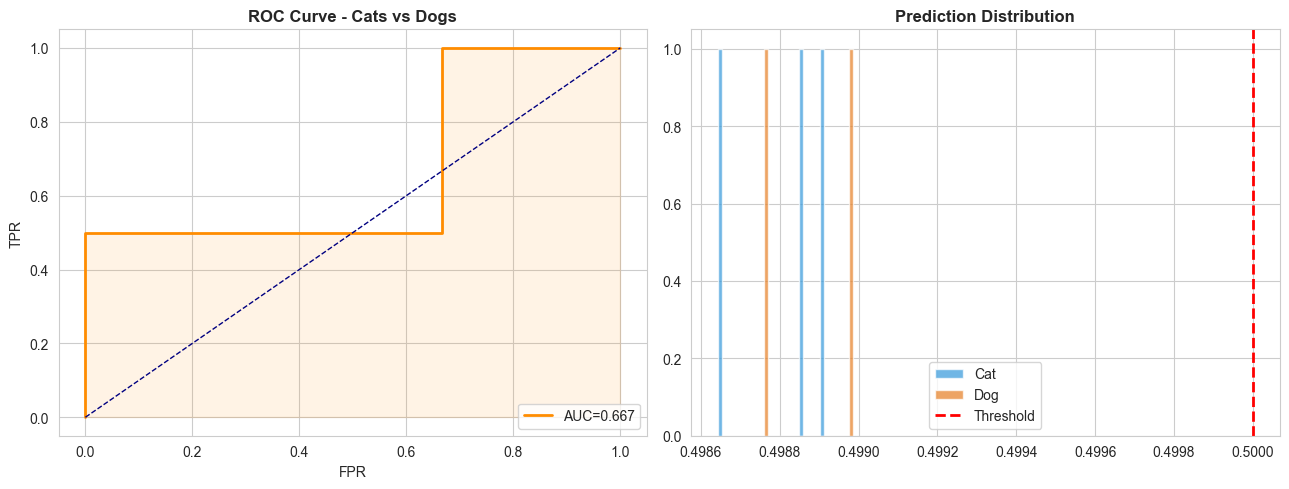

ROC-AUC: 0.6667


In [27]:
fpr,tpr,_ = roc_curve(yte2, yp2_prob)
roc_auc_val = auc(fpr, tpr)
fig,ax=plt.subplots(1,2,figsize=(13,5))
ax[0].plot(fpr,tpr,color='darkorange',lw=2,label=f'AUC={roc_auc_val:.3f}')
ax[0].plot([0,1],[0,1],'navy',lw=1,ls='--'); ax[0].fill_between(fpr,tpr,alpha=0.1,color='darkorange')
ax[0].set_title('ROC Curve - Cats vs Dogs',fontweight='bold')
ax[0].set_xlabel('FPR'); ax[0].set_ylabel('TPR'); ax[0].legend(loc='lower right')
ax[1].hist(yp2_prob[yte2==0],bins=25,alpha=0.7,color='#3498DB',label='Cat')
ax[1].hist(yp2_prob[yte2==1],bins=25,alpha=0.7,color='#E67E22',label='Dog')
ax[1].axvline(0.5,color='red',ls='--',lw=2,label='Threshold')
ax[1].set_title('Prediction Distribution',fontweight='bold'); ax[1].legend()
plt.tight_layout(); plt.show()
print(f"ROC-AUC: {roc_auc_val:.4f}")


---
## 📊 PHẦN 3: Tổng Kết

TỔNG KẾT KẾT QUẢ

Dataset                Test Acc   Best Val      Gap   Epochs Status
----------------------------------------------------------------------
PlantVillage (3cls)  SKIPPED             
Cats vs Dogs (bin)       60.00%     60.00%    5.00%      16  ⚠️ <90% no overfit✅


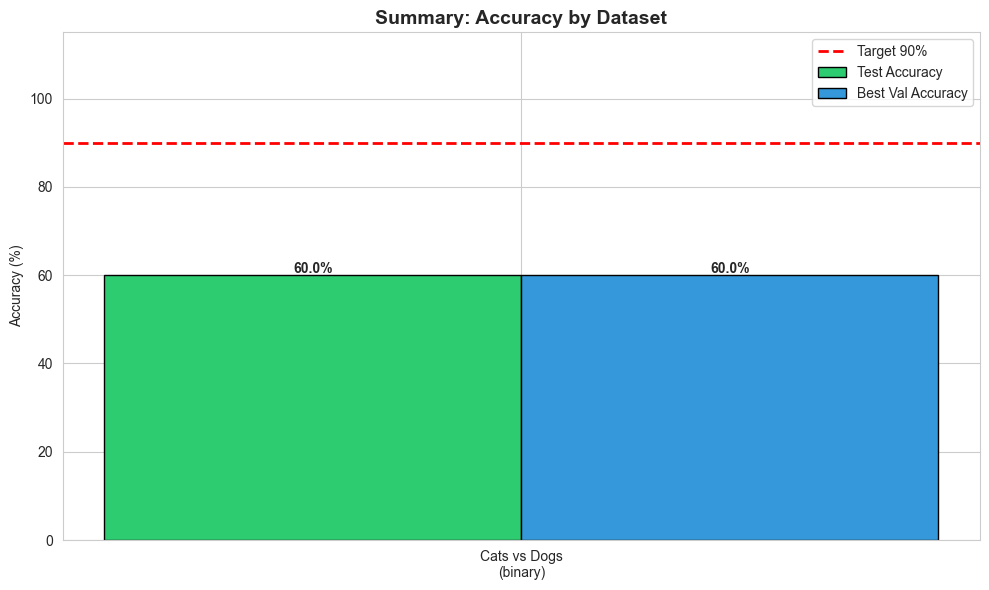

In [30]:
print("="*65)
print("TỔNG KẾT KẾT QUẢ")
print("="*65)

def get_stats(h, ta):
    bv=max(h.history['val_accuracy'])
    ft=h.history['accuracy'][-1]; fv=h.history['val_accuracy'][-1]
    return {'test':ta,'best_val':bv,'train':ft,'val':fv,'epochs':len(h.history['accuracy']),'gap':abs(ft-fv)}

if PLANT_AVAILABLE:
    s1=get_stats(history_plant, ta)
else:
    s1={'test':0,'best_val':0,'train':0,'val':0,'epochs':0,'gap':0}

s2=get_stats(history_cd, ta2)

print(f"\n{'Dataset':<20} {'Test Acc':>10} {'Best Val':>10} {'Gap':>8} {'Epochs':>8} {'Status'}")
print("-"*70)
if PLANT_AVAILABLE:
    nm,s = "PlantVillage (3cls)", s1
    ok = "✅ >90%" if s['test']>=0.90 else "⚠️ <90%"
    ov = "no overfit✅" if s['gap']<0.07 else "overfit⚠️"
    print(f"{nm:<20} {s['test']*100:>9.2f}% {s['best_val']*100:>9.2f}% {s['gap']*100:>7.2f}% {s['epochs']:>7}  {ok} {ov}")
else:
    print(f"{'PlantVillage (3cls)':<20} {'SKIPPED':<20}")

nm,s = "Cats vs Dogs (bin)", s2
ok = "✅ >90%" if s['test']>=0.90 else "⚠️ <90%"
ov = "no overfit✅" if s['gap']<0.07 else "overfit⚠️"
print(f"{nm:<20} {s['test']*100:>9.2f}% {s['best_val']*100:>9.2f}% {s['gap']*100:>7.2f}% {s['epochs']:>7}  {ok} {ov}")
print("="*65)

# Bar chart
fig,ax=plt.subplots(figsize=(10,6))

if PLANT_AVAILABLE:
    # Two-dataset case
    x=np.arange(2); w=0.3
    taccs=[s1['test']*100, s2['test']*100]
    bvals=[s1['best_val']*100, s2['best_val']*100]
    
    b1=ax.bar(x-w/2, taccs, w, label='Test Accuracy', color='#2ECC71', edgecolor='black')
    b2=ax.bar(x+w/2, bvals, w, label='Best Val Accuracy', color='#3498DB', edgecolor='black')
    
    dsets=['PlantVillage\n(3-class)','Cats vs Dogs\n(binary)']
    ax.set_xticks(x); ax.set_xticklabels(dsets)
    
    for b in list(b1)+list(b2): 
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{b.get_height():.1f}%', ha='center', fontweight='bold')
    
    ax.axhline(90, color='red', ls='--', lw=2, label='Target 90%')
    ax.set_ylabel('Accuracy (%)'); ax.set_ylim([0,115]); ax.legend()
    ax.set_title('Summary: Accuracy by Dataset', fontweight='bold', fontsize=14)

else:
    # Single-dataset case (only Cats vs Dogs)
    x=np.arange(1); w=0.3
    taccs=[s2['test']*100]
    bvals=[s2['best_val']*100]
    
    b1=ax.bar(x-w/2, taccs, w, label='Test Accuracy', color='#2ECC71', edgecolor='black')
    b2=ax.bar(x+w/2, bvals, w, label='Best Val Accuracy', color='#3498DB', edgecolor='black')
    
    dsets=['Cats vs Dogs\n(binary)']
    ax.set_xticks(x); ax.set_xticklabels(dsets)
    
    for b in list(b1)+list(b2):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f'{b.get_height():.1f}%', ha='center', fontweight='bold')
    
    ax.axhline(90, color='red', ls='--', lw=2, label='Target 90%')
    ax.set_ylabel('Accuracy (%)'); ax.set_ylim([0,115]); ax.legend()
    ax.set_title('Summary: Accuracy by Dataset', fontweight='bold', fontsize=14)

plt.tight_layout(); plt.show()

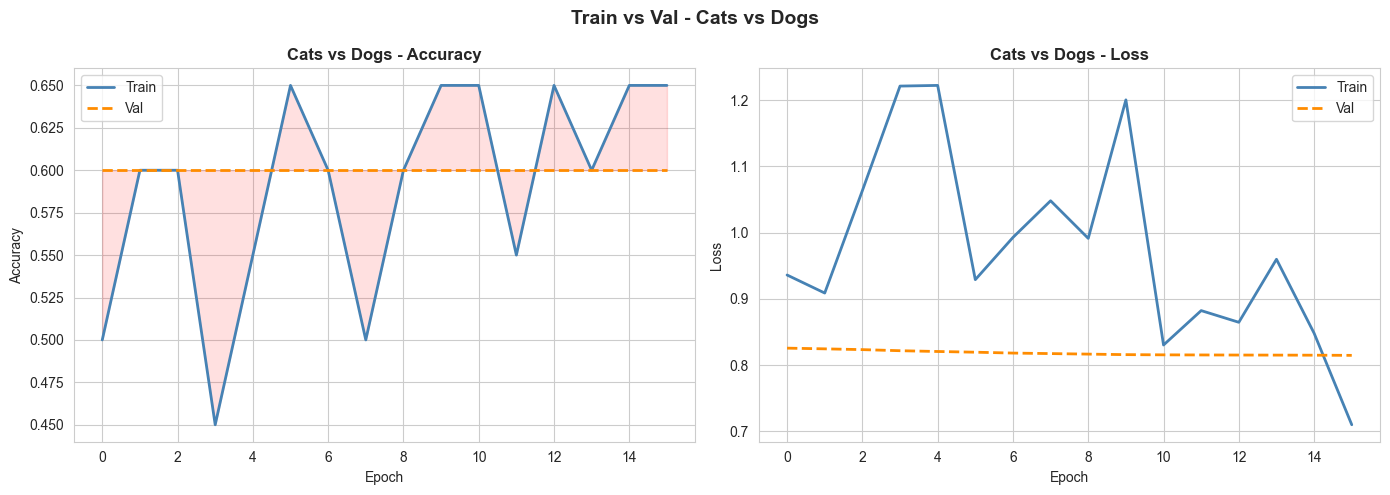

In [31]:
if PLANT_AVAILABLE:
    fig,axes=plt.subplots(2,2,figsize=(14,10))
    fig.suptitle('Train vs Val - Overfitting Analysis',fontweight='bold',fontsize=14)

    for row,(h,title) in enumerate([(history_plant,'PlantVillage'),(history_cd,'Cats vs Dogs')]):
        ep=range(len(h.history['accuracy']))
        # Accuracy
        axes[row][0].plot(h.history['accuracy'],label='Train',lw=2,color='steelblue')
        axes[row][0].plot(h.history['val_accuracy'],label='Val',lw=2,color='darkorange',ls='--')
        axes[row][0].fill_between(ep,h.history['accuracy'],h.history['val_accuracy'],alpha=0.12,color='red')
        axes[row][0].set_title(f'{title} - Accuracy',fontweight='bold')
        axes[row][0].set_xlabel('Epoch'); axes[row][0].set_ylabel('Accuracy'); axes[row][0].legend()
        # Loss
        axes[row][1].plot(h.history['loss'],label='Train',lw=2,color='steelblue')
        axes[row][1].plot(h.history['val_loss'],label='Val',lw=2,color='darkorange',ls='--')
        axes[row][1].set_title(f'{title} - Loss',fontweight='bold')
        axes[row][1].set_xlabel('Epoch'); axes[row][1].set_ylabel('Loss'); axes[row][1].legend()

    plt.tight_layout(); plt.show()

else:
    fig,axes=plt.subplots(1,2,figsize=(14,5))
    fig.suptitle('Train vs Val - Cats vs Dogs',fontweight='bold',fontsize=14)
    
    h = history_cd
    ep=range(len(h.history['accuracy']))
    # Accuracy
    axes[0].plot(h.history['accuracy'],label='Train',lw=2,color='steelblue')
    axes[0].plot(h.history['val_accuracy'],label='Val',lw=2,color='darkorange',ls='--')
    axes[0].fill_between(ep,h.history['accuracy'],h.history['val_accuracy'],alpha=0.12,color='red')
    axes[0].set_title('Cats vs Dogs - Accuracy',fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()
    # Loss
    axes[1].plot(h.history['loss'],label='Train',lw=2,color='steelblue')
    axes[1].plot(h.history['val_loss'],label='Val',lw=2,color='darkorange',ls='--')
    axes[1].set_title('Cats vs Dogs - Loss',fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
    
    plt.tight_layout(); plt.show()

In [32]:
print("="*60)
print("KỸ THUẬT CHỐNG OVERFITTING ĐÃ ÁP DỤNG")
print("="*60)
techs=[
    (" Batch Normalization",  "Sau mỗi Conv → ổn định gradient"),
    (" Dropout (0.2-0.5)",    "Tăng dần ở head, SpatialDropout ở Conv"),
    (" Data Augmentation",    "Rotation/Flip/Zoom/Shift/Brightness"),
    (" L2 Regularization",    "l2(1e-4) trên tất cả Conv & Dense"),
    (" GlobalAvgPooling2D",   "Thay Flatten → giảm params"),
    (" EarlyStopping",        "Patience=15, restore best weights"),
    (" ReduceLROnPlateau",    "LR ÷2 khi val_loss đứng yên 6 epochs"),
    (" Class Weighting",      "Bù imbalance cho PlantVillage"),
    (" Stratified Split",     "Giữ nguyên tỉ lệ class ở tất cả splits"),
]
for t,d in techs: print(f"  {t:<30} {d}")
print("\nKIẾN TRÚC: Custom CNN (4 blocks Dual-Conv) - KHÔNG dùng ResNet/pretrained!")
print("="*60)


KỸ THUẬT CHỐNG OVERFITTING ĐÃ ÁP DỤNG
   Batch Normalization           Sau mỗi Conv → ổn định gradient
   Dropout (0.2-0.5)             Tăng dần ở head, SpatialDropout ở Conv
   Data Augmentation             Rotation/Flip/Zoom/Shift/Brightness
   L2 Regularization             l2(1e-4) trên tất cả Conv & Dense
   GlobalAvgPooling2D            Thay Flatten → giảm params
   EarlyStopping                 Patience=15, restore best weights
   ReduceLROnPlateau             LR ÷2 khi val_loss đứng yên 6 epochs
   Class Weighting               Bù imbalance cho PlantVillage
   Stratified Split              Giữ nguyên tỉ lệ class ở tất cả splits

KIẾN TRÚC: Custom CNN (4 blocks Dual-Conv) - KHÔNG dùng ResNet/pretrained!
